## CMPINF 2100 Week 11
### Introduction to fitting LOGISTIC REGRESSION with statsmodels

Logistic regression is a model type for BINARY CLASSIFICATION.

However, logistic regression is a generalized linear Model or GLM. Therefore, almost everything from Linear Models (LM) applies!!

We can use everything about creating features, additive features, non-linear features derived from inputs.

There are several key differences which we will learn abouot next week

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Read data

In [4]:
df = pd.read_csv('week_11_intro_binary_classification.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       115 non-null    float64
 1   y       115 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.9 KB


In [6]:
df.nunique()

x    115
y      2
dtype: int64

In [7]:
df.y.value_counts()

y
0    67
1    48
Name: count, dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


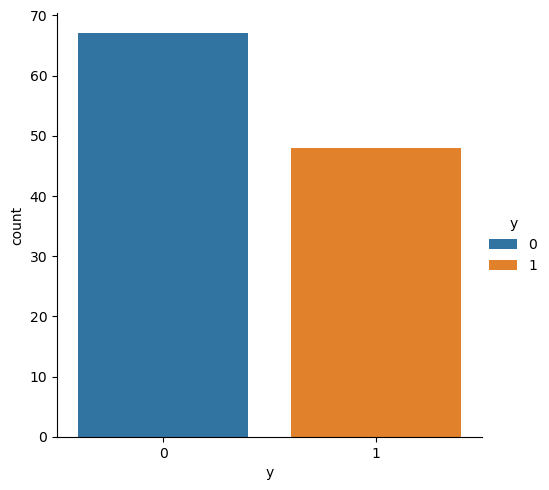

In [9]:
sns.catplot(data = df, x='y', kind='count', hue='y' )

plt.show()

In [10]:
df.describe()

,x,y
count,115.000000,115.000000
mean,0.019188,0.417391
std,1.001227,0.495287
min,-2.059272,0.000000
25%,-0.721905,0.000000
50%,0.114752,0.000000
75%,0.570510,1.000000
max,2.438859,1.000000


In [11]:
df.y.mean()

0.41739130434782606

In [12]:
df.y.value_counts(normalize=True)

y
0    0.582609
1    0.417391
Name: proportion, dtype: float64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


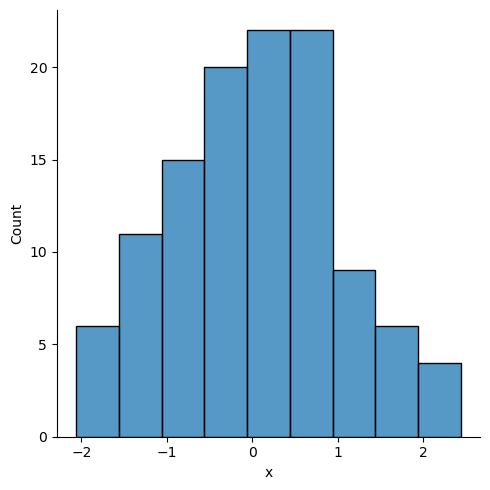

In [13]:
sns.displot(data = df, x='x', kind='hist')
plt.show()

How does the continuous input RELATE to the categorical output??!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


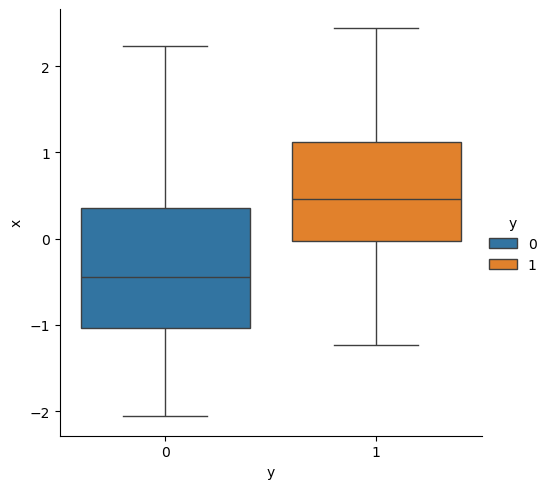

In [17]:
sns.catplot(data = df, x='y', y='x', kind='box', hue='y')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


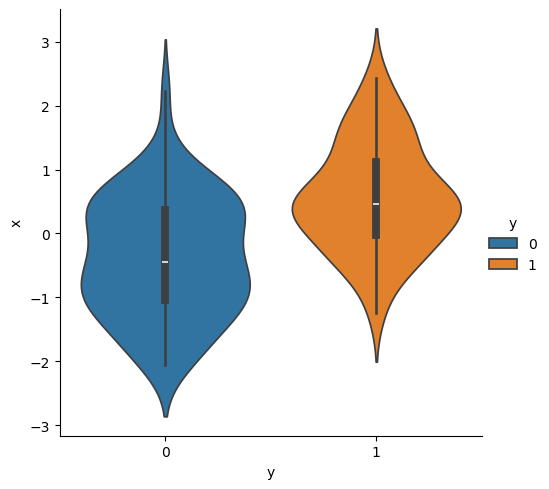

In [20]:
sns.catplot(data = df, x='y', y='x', kind='violin', hue='y')
plt.show()

What is the AVERAGE continuous INPUT **GIVEN** the Binary output?!!

/var/folders/w2/67mk25c54mj4_5lpd9wgfrxm0000gq/T/ipykernel_11309/253218392.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot( data = df, x='y', y='x', kind='point', join=False)
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


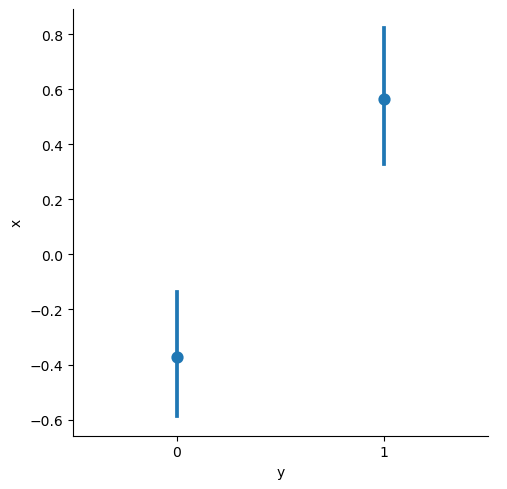

In [21]:
sns.catplot( data = df, x='y', y='x', kind='point', join=False)
plt.show()

On average there seems to be a DIFFERENCE in the INPUT when the EVENT is observed!!!

The visual exploration suggests that the INPUT is RELATED to the BINARY OUTPUT!!!

## Fit logistic regression

The syntax for fitting a logistic regression model for Binary Classification is very similar to that for the linear model for regression!!!!

However, we must tell statsmodels that this is a logistic regression problem and NOT regression!!!

In [22]:
fit_glm = smf.logit(formula='y ~ x', data=df).fit()

Optimization terminated successfully.
         Current function value: 0.560099
         Iterations 6


Let's see what happens if we would MISTAKENLY fit the LINEAR MODEL for regression!!!

In [23]:
fit_ols = smf.ols(formula='y ~ x', data=df).fit()

But because logistic is a Generalized Linear Model, many of the interpretation concepts still apply!!!

In [26]:
fit_glm.params

Intercept   -0.449518
x            1.183814
dtype: float64

In [27]:
fit_glm.bse

Intercept    0.218009
x            0.267133
dtype: float64

In [28]:
fit_glm.pvalues

Intercept    0.039215
x            0.000009
dtype: float64

In [30]:
fit_glm.conf_int().\
rename(columns={0:'conf_lwr', 1:'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.876808,-0.022228
x,0.660243,1.707385


In [31]:
fit_glm.pvalues < 0.05

Intercept    True
x            True
dtype: bool

In [32]:
def my_coefplot(mod, figsize_use=(10, 4)):
    fig, ax = plt.subplots(figsize=figsize_use)
    ax.errorbar(y=mod.params.index,
               x=mod.params,
               xerr = 2 * mod.bse,
               fmt= 'o', color='k', ecolor='k', elinewidth=2, ms=10)
    ax.axvline(x=0, linestyle='--', linewidth=3.5, color='grey')
    ax.set_xlabel('coefficient value')
    plt.show()

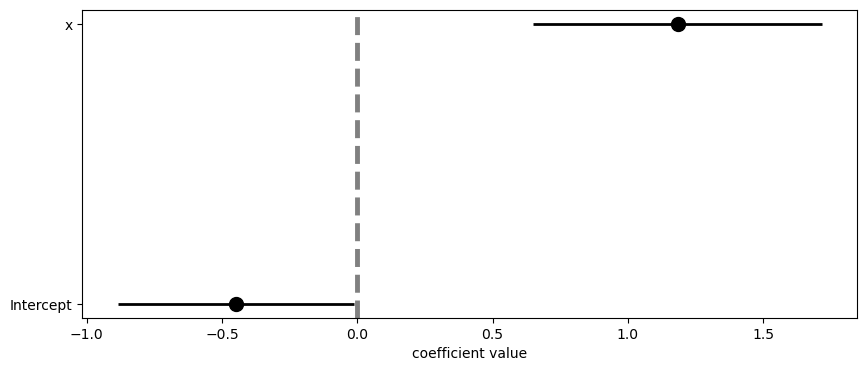

In [33]:
my_coefplot( fit_glm )

The DIFFERENCE between the interpretation of the logistic regression SLOPE vs the "regular" linear model SLOPE is that...the logistic regression slope is **NOT** how much the AVERAGE OUTPUT changes due to a one unit change of the INPUT!!!

The slope is how much the LOG ODDS RATIO CHANGES as the input changes 1 unit!!!

## Predictions

Fundamentally we are predicting the event probability!!!

The `.predict()` therefore returns the predicted probability!!!

Define a VISUALIZATION GRID between a VERY NEGATIVE INPUT and a VERY POSITIVE INPUT

In [34]:
df.describe()

,x,y
count,115.000000,115.000000
mean,0.019188,0.417391
std,1.001227,0.495287
min,-2.059272,0.000000
25%,-0.721905,0.000000
50%,0.114752,0.000000
75%,0.570510,1.000000
max,2.438859,1.000000


Let's use a lower bound of -5 and an upper bound of 5 for the input in the visualization grid

In [35]:
input_grid = pd.DataFrame({'x':np.linspace(-5, 5, num=251)})

In [36]:
input_grid

,x
0,-5.00
1,-4.96
2,-4.92
3,-4.88
4,-4.84
...,...
246,4.84
247,4.88
248,4.92
249,4.96


Define a copy of the input grid

In [37]:
df_viz = input_grid.copy()

Include a new column for the PREDICTED PROBABILITY from the logistic regression model!

In [38]:
df_viz['pred_probability'] = fit_glm.predict(input_grid)

In [39]:
df_viz

,x,pred_probability
0,-5.00,0.001712
1,-4.96,0.001794
2,-4.92,0.001881
3,-4.88,0.001972
4,-4.84,0.002068
...,...,...
246,4.84,0.994934
247,4.88,0.995167
248,4.92,0.995390
249,4.96,0.995602


In [40]:
df_viz.describe()

,x,pred_probability
count,251.000000,251.000000
mean,0.000000,0.462384
std,2.904066,0.406932
min,-5.000000,0.001712
25%,-2.500000,0.032022
50%,0.000000,0.389475
75%,2.500000,0.924824
max,5.000000,0.995805


Visualize the predicted probability with respect to the INPUT in the visualization grid...

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


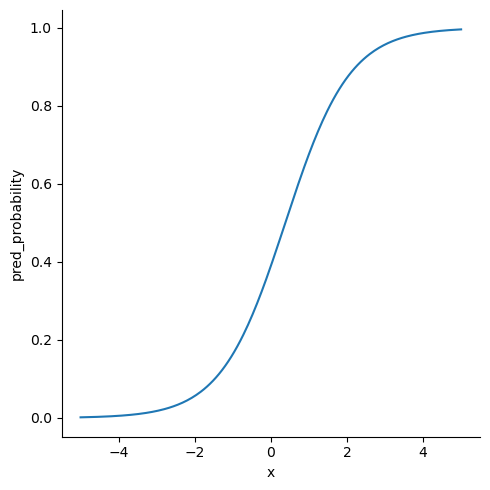

In [41]:
sns.relplot(data = df_viz, x='x', y='pred_probability', kind='line')
plt.show()

Why does this matter??
What happens if we MISTAKENLY fit the Regular linear model???

In [42]:
fit_ols.params

Intercept    0.412996
x            0.229045
dtype: float64

In [43]:
fit_ols.bse

Intercept    0.041125
x            0.041247
dtype: float64

In [44]:
fit_ols.pvalues

Intercept    2.405283e-17
x            1.884900e-07
dtype: float64

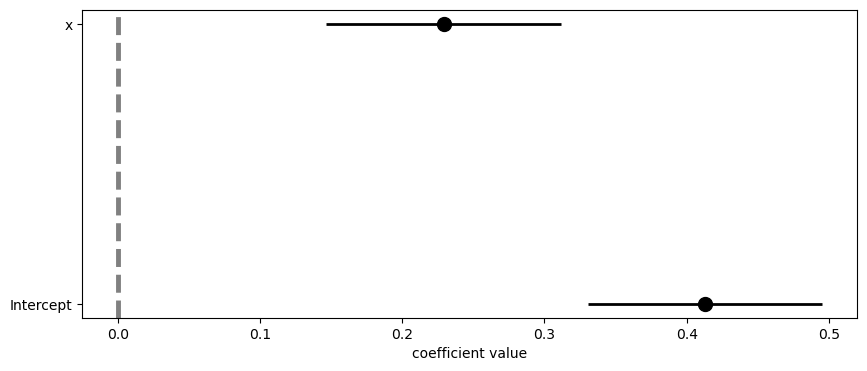

In [45]:
my_coefplot(fit_ols)

Predit with the incorrect linear model

In [47]:
df_viz['pred_from_ols'] = fit_ols.predict( input_grid )

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


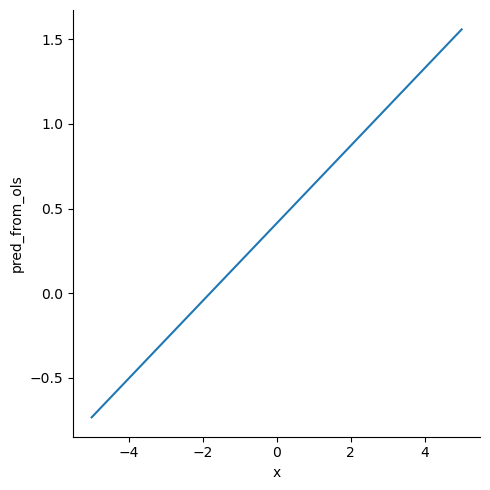

In [48]:
sns.relplot( data = df_viz, x='x', y='pred_from_ols', kind='line')
plt.show()

## Visually explore the logistic trends
The `sns.lmplot()` function allows you to visualize the logistic regression fit!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


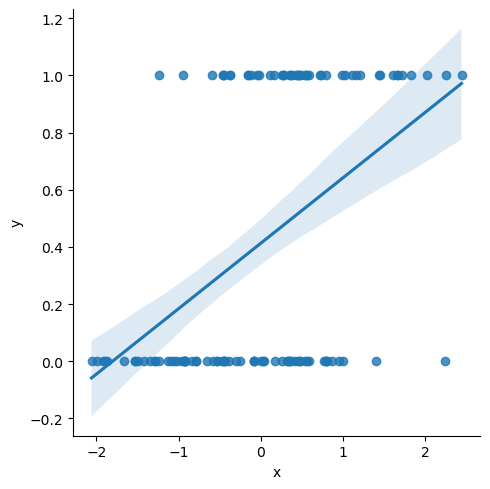

In [50]:
sns.lmplot(data = df, x='x', y='y')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


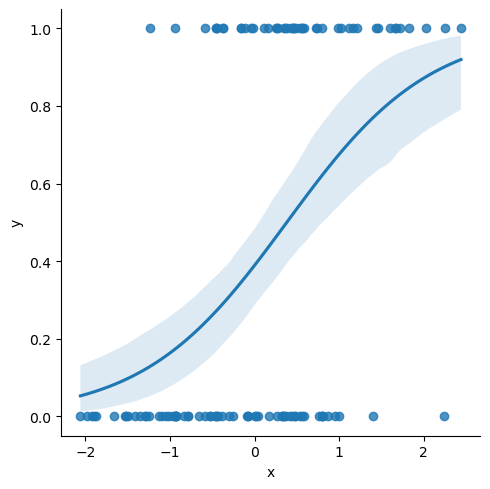

In [51]:
sns.lmplot(data = df, x='x', y='y', logistic=True)
plt.show()